In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

save_path = 'saved_model_td3/260105/taining_num_1'

return_td3 = np.load(os.path.join(save_path, 'return_list.npy'))
return_ppo = np.load(os.path.join(save_path, 'return_list_PPO.npy'))

print(f'TD3  episodes: {len(return_td3)}, min: {return_td3.min():.1f}, mean: {return_td3.mean():.1f}, max: {return_td3.max():.1f}')
print(f'PPO  episodes: {len(return_ppo)}, min: {return_ppo.min():.1f}, mean: {return_ppo.mean():.1f}, max: {return_ppo.max():.1f}')

TD3  episodes: 20000, min: -13635.6, mean: 9279.3, max: 17809.9
PPO  episodes: 20000, min: -16463.8, mean: -2245.9, max: 5593.1


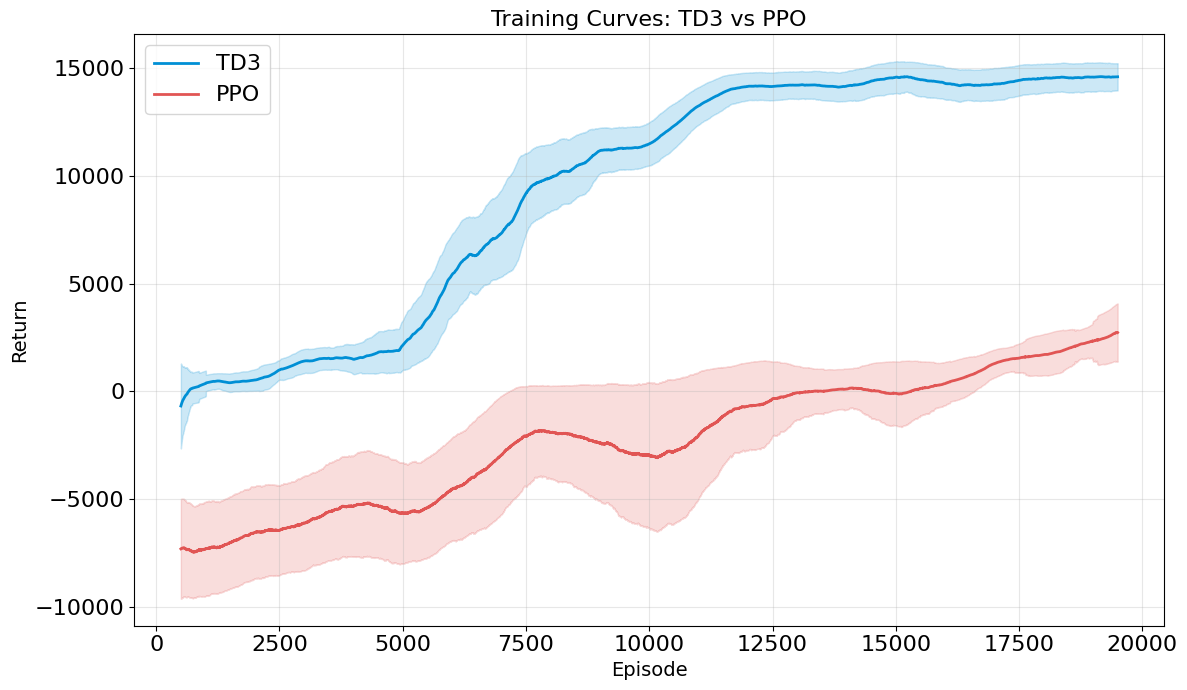

In [2]:
window_size = max(1, len(return_td3) // 20)

def smooth(arr):
    s = pd.Series(arr)
    return s.rolling(window=window_size, center=True).mean(), s.rolling(window=window_size, center=True).std()

steps = np.arange(len(return_td3))
td3_mean, td3_std = smooth(return_td3)
ppo_mean, ppo_std = smooth(return_ppo)

fig, ax = plt.subplots(figsize=(12, 7))

# TD3
ax.plot(steps, td3_mean, linewidth=2, color='#008FD5', label='TD3')
ax.fill_between(steps, td3_mean - td3_std, td3_mean + td3_std, alpha=0.2, color='#008FD5')

# PPO
ax.plot(steps, ppo_mean, linewidth=2, color='#E15554', label='PPO')
ax.fill_between(steps, ppo_mean - ppo_std, ppo_mean + ppo_std, alpha=0.2, color='#E15554')

ax.set_xlabel('Episode', fontsize=14)
ax.set_ylabel('Return', fontsize=14)
ax.set_title('Training Curves: TD3 vs PPO', fontsize=16)
ax.tick_params(axis='both', labelsize=16)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=16)
plt.tight_layout()
plt.show()